In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import time
import tensorflow as tf
import tensorflow.python.keras
import matplotlib.pyplot as plt


In [2]:
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from glob import glob

In [3]:
IMAGE_SIZE = [224,224]

In [4]:
# Create InceptionV3 Layer
rn = ResNet50(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE + [3])
for layer in rn.layers:
  layer.trainable = False

In [5]:
# we will use the glob to see how many outputs / labels there are
folders = glob('./plantvillage/*')

In [6]:
folders

['./plantvillage\\Tomato___Bacterial_spot',
 './plantvillage\\Tomato___Early_blight',
 './plantvillage\\Tomato___healthy',
 './plantvillage\\Tomato___Late_blight',
 './plantvillage\\Tomato___Leaf_Mold',
 './plantvillage\\Tomato___Septoria_leaf_spot',
 './plantvillage\\Tomato___Spider_mites Two-spotted_spider_mite',
 './plantvillage\\Tomato___Target_Spot',
 './plantvillage\\Tomato___Tomato_mosaic_virus',
 './plantvillage\\Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [7]:
# Add Flatten and Dense in last layers
x = GlobalAveragePooling2D()(rn.output)
x = Dropout(0.5)(x)
prediction = Dense(len(folders),activation='softmax')(x)

In [8]:
model = Model(inputs=rn.input,outputs = prediction)
plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
# Compile the model that we have created with adam and the loss is categorical_crossentropy because the classification is more than 2 classes
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Then use the CustomImageDataGenerator instead of ImageDataGenerator
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=10,           # Very small rotations
    width_shift_range=0.05,      # Minimal shifts
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,              # Small zoom
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)
test_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

In [12]:
# Load training and validation data using tf.data.Dataset
training_set = train_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='training',
    shuffle = True
)

val_set = val_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='validation'
)

test_dataset = test_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size = 8,
    class_mode = 'categorical',
    shuffle = False

)


Found 12855 images belonging to 10 classes.
Found 2567 images belonging to 10 classes.
Found 12855 images belonging to 10 classes.


In [13]:
print(training_set)
print(val_set)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [15]:
tic = time.perf_counter()
history = model.fit(training_set,
                    steps_per_epoch=len(training_set),
                    validation_data=val_set,
                    validation_steps=len(val_set),
                    epochs=20, callbacks=[early_stopping, reduce_lr])
# time
toc = time.perf_counter()
model.save('resnet50test.keras')


c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.3226 - loss: 2.0487

c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1363s 845ms/step - accuracy: 0.3226 - loss: 2.0487 - val_accuracy: 0.4079 - val_loss: 1.7818 - learning_rate: 0.0010
Epoch 2/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1179s 734ms/step - accuracy: 0.3691 - loss: 1.8624 - val_accuracy: 0.4433 - val_loss: 1.7120 - learning_rate: 0.0010
Epoch 3/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1169s 727ms/step - accuracy: 0.4002 - loss: 1.7960 - val_accuracy: 0.4655 - val_loss: 1.6470 - learning_rate: 0.0010
Epoch 4/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1223s 761ms/step - accuracy: 0.4055 - loss: 1.7622 - val_accuracy: 0.4577 - val_loss: 1.6589 - learning_rate: 0.0010
Epoch 5/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1190s 740ms/step - accuracy: 0.4107 - loss: 1.7393 - val_accuracy: 0.4799 - val_loss: 1.5664 - learning_rate: 0.0010
Epoch 6/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1177s 732ms/step - accuracy: 0.4269 - loss: 1.7068 - val_accuracy: 0.4823 - val_loss: 1.5403 - learning_rate: 0.0010
Epoch 7/20
1607/1607 ━━━━━━━━━━━━━━━━━━━━ 1229s 765ms/ste

In [16]:
print("Total Time:{}".format(round((toc-tic)/60,2)))

Total Time:401.81


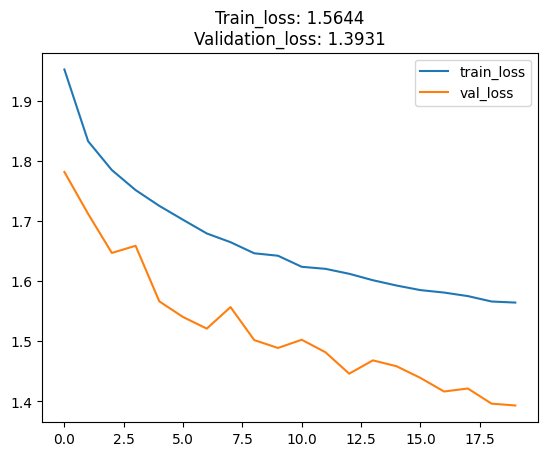

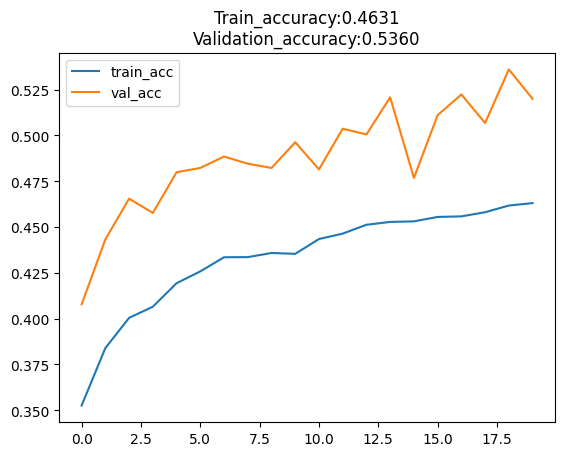

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label='train_loss')
plt.plot(val_loss,label = 'val_loss')
plt.legend()
plt.title("Train_loss: {:.4f}".format(history.history['loss'][-1]) +
          "\nValidation_loss: {:.4f}".format(history.history['val_loss'][-1]))
plt.show()

plt.plot(acc, label='train_acc')
plt.plot(val_acc,label = 'val_acc')
plt.title("Train_accuracy:{:.4f}".format(max(history.history['accuracy']))+
         "\nValidation_accuracy:{:.4f}".format(max(history.history['val_accuracy'])))
plt.legend()
plt.show()

In [18]:
scores = model.evaluate(test_dataset)

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 912s 568ms/step - accuracy: 0.2910 - loss: 1.8546


In [19]:
y_pred = model.predict(test_dataset)    

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 934s 580ms/step


In [20]:
y_predict = np.argmax(y_pred,axis=1)
y_predict

array([7, 7, 7, ..., 9, 9, 9], dtype=int64)

In [21]:
y_true = test_dataset.classes
y_true

array([0, 0, 0, ..., 9, 9, 9])

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
class_name = ['Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']

In [24]:
print(classification_report(y_true,y_predict,target_names = class_name))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.00      0.00      0.00        28
                        Tomato_Early_blight       0.52      0.05      0.09       800
                         Tomato_Late_blight       0.50      0.22      0.31      1527
                           Tomato_Leaf_Mold       0.00      0.00      0.00       761
                  Tomato_Septoria_leaf_spot       0.48      0.35      0.40      1417
Tomato_Spider_mites_Two_spotted_spider_mite       0.41      0.70      0.52      1341
                        Tomato__Target_Spot       0.58      0.04      0.08      1123
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.60      0.90      0.72      4286
                Tomato__Tomato_mosaic_virus       0.27      0.01      0.02       299
                             Tomato_healthy       0.42      0.76      0.54      1273

                                   accuracy                    

c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [25]:
import seaborn as sns

In [26]:
cm = confusion_matrix(y_true,y_predict)
cm

array([[   0,    0,    0,    0,    0,    0,    0,   28,    0,    0],
       [   0,   39,   68,    0,  139,   78,   10,  377,    0,   89],
       [   0,    7,  337,    0,  148,  134,    8,  753,    0,  140],
       [   0,    4,  107,    0,  114,   85,    0,  389,    3,   59],
       [   0,   14,   90,    0,  490,  116,    6,  477,    4,  220],
       [   0,    1,   19,    0,   35,  941,    6,   95,    0,  244],
       [   0,    8,   25,    0,   68,  370,   50,   71,    1,  530],
       [   0,    2,   22,    0,   21,  354,    3, 3859,    0,   25],
       [   0,    0,    5,    0,    1,  169,    0,   88,    3,   33],
       [   0,    0,    1,    0,    5,   27,    3,  272,    0,  965]],
      dtype=int64)

In [27]:
cm_normalized = np.round(cm/np.sum(cm,axis=1).reshape(-1,1),2)
print(cm_normalized)

[[0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.05 0.08 0.   0.17 0.1  0.01 0.47 0.   0.11]
 [0.   0.   0.22 0.   0.1  0.09 0.01 0.49 0.   0.09]
 [0.   0.01 0.14 0.   0.15 0.11 0.   0.51 0.   0.08]
 [0.   0.01 0.06 0.   0.35 0.08 0.   0.34 0.   0.16]
 [0.   0.   0.01 0.   0.03 0.7  0.   0.07 0.   0.18]
 [0.   0.01 0.02 0.   0.06 0.33 0.04 0.06 0.   0.47]
 [0.   0.   0.01 0.   0.   0.08 0.   0.9  0.   0.01]
 [0.   0.   0.02 0.   0.   0.57 0.   0.29 0.01 0.11]
 [0.   0.   0.   0.   0.   0.02 0.   0.21 0.   0.76]]


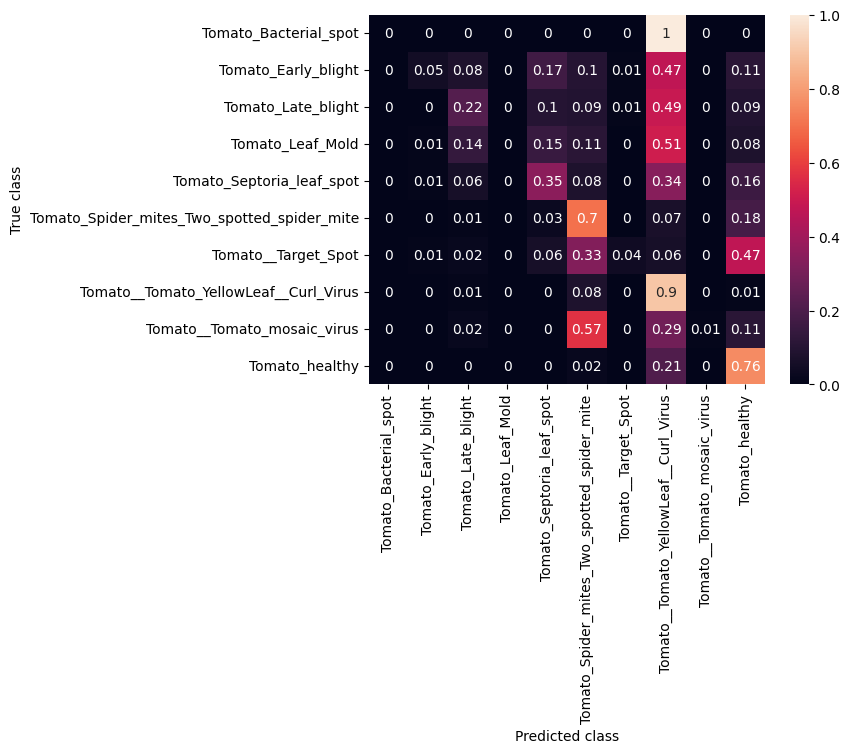

In [28]:
sns.heatmap(cm_normalized, annot=True,xticklabels=class_name, yticklabels=class_name,)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.show()

In [29]:
import pickle
# Save the history object to a file
with open('history_resnet50.pkl', 'wb') as file:
    pickle.dump(history.history, file)